In [26]:
# general
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm # if this line throws an error, type "conda install tqdm" in your terminal to install tqdm

# plotting
import matplotlib
import matplotlib.pyplot as plt

# my functions/classes
import sys
sys.path.append("../core_scripts/")
from ECMclass import ECM

In [27]:
# smoothing window, mm
window = 10

# paths
global path_to_data, path_to_figures, path_to_metadata, metadata_file
path_to_data = '../../data/'
path_to_figures = '../../figures/average_oneline/'
path_to_metadata = '../../data/'
metadata_file = 'metadata.csv'

In [28]:
metadata = pd.read_csv(path_to_metadata + metadata_file, index_col=0)

# filter for core = ALHIC2501, ACorDC = 'AC', and num_tracks = 7
metadata_DC = metadata[(metadata['core'] == 'ALHIC2501') & (metadata['ACorDC'] == 'DC') & (metadata['num_tracks'] == 7)]

metadata_AC = metadata[(metadata['core'] == 'ALHIC2501') & (metadata['ACorDC'] == 'AC') & (metadata['num_tracks'] == 6)]

In [32]:
data_DC = []

# load all of the data files for the filtered metadata
for index, row in tqdm(
    metadata_DC.iterrows(),
    total=len(metadata_DC),
    desc="Loading data files"
):
    # load the ECM data
    if os.path.exists(
        path_to_data + 'clean/' + row['core'] + '/' +
        row['core'] + '-' + row['section'] + '-' +
        row['face'] + '-' + row['ACorDC'] + '.csv'
    ):
        path_to_file = path_to_data + 'clean/'
    else:
        path_to_file = path_to_data + 'not-cleaned/'

    data_item = ECM(
        row['core'], row['section'], row['face'], row['ACorDC'],
        path_to_file, path_to_metadata + metadata_file
    )
    data_item.rem_ends(20)
    #data_item.norm_all()

    data_DC.append(data_item)


Loading data files:   0%|          | 0/170 [00:00<?, ?it/s]

In [35]:
data_AC = []

# load all of the data files for the filtered metadata
for index, row in tqdm(
    metadata_AC.iterrows(),
    total=len(metadata_AC),
    desc="Loading data files"
):
    # load the ECM data
    if os.path.exists(
        path_to_data + 'clean/' + row['core'] + '/' +
        row['core'] + '-' + row['section'] + '-' +
        row['face'] + '-' + row['ACorDC'] + '.csv'
    ):
        path_to_file = path_to_data + 'clean/'
    else:
        path_to_file = path_to_data + 'not-cleaned/'

    data_item = ECM(
        row['core'], row['section'], row['face'], row['ACorDC'],
        path_to_file, path_to_metadata + metadata_file
    )
    data_item.rem_ends(20)
    #data_item.norm_all()

    data_AC.append(data_item)


Loading data files:   0%|          | 0/169 [00:00<?, ?it/s]

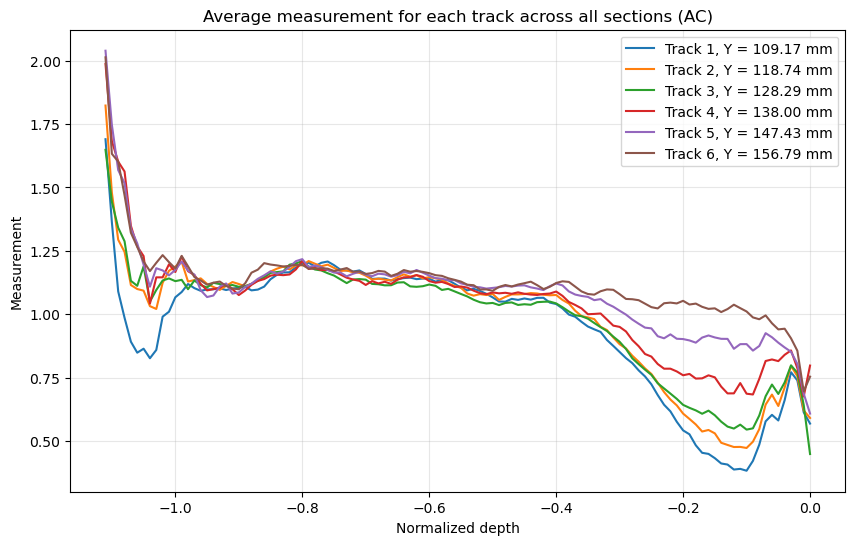

In [38]:
# Average each of the seven tracks across all sections

track_data = []

for section_index, d in enumerate(data_DC):
    depth = np.asarray(d.depth, dtype=float)
    measurements = np.asarray(d.meas, dtype=float)
    y_values = np.asarray(d.y, dtype=float)

    # Normalize depth within each section
    depth = depth - np.nanmax(depth)
    #depth = depth - np.nanmin(depth)
    #depth_range = np.nanmax(depth)
    # if depth_range > 0:
    #     depth = depth / depth_range

    # normalize measurements within each section
    measurements = measurements / np.nanmean(measurements)

    # Assign tracks by their ordered Y positions
    track_positions = np.sort(np.unique(y_values[np.isfinite(y_values)]))

    for track_index, y_value in enumerate(track_positions):
        mask = (
            (y_values == y_value)
            & np.isfinite(depth)
            & np.isfinite(measurements)
        )

        if not np.any(mask):
            continue

        bin_index = np.floor(depth[mask] * 100).astype(int)

        track_data.append(pd.DataFrame({
            "track": track_index + 1,
            "bin_start": bin_index / 100,
            "measurement": measurements[mask],
            "y_value": y_value,
        }))

# Combine all sections and average by track and normalized depth
all_tracks = pd.concat(track_data, ignore_index=True)

average_tracks = (
    all_tracks
    .groupby(["track", "bin_start"], as_index=False)
    .agg(
        measurement=("measurement", "mean"),
        y_value=("y_value", "mean")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

for track, track_average in average_tracks.groupby("track"):
    ax.plot(
        track_average["bin_start"],
        track_average["measurement"],
        label=f"Track {track}, Y = {track_average['y_value'].mean():.2f} mm"
    )

ax.set_title("Average measurement for each track across all sections (AC)")
ax.set_xlabel("Normalized depth")
ax.set_ylabel("Measurement")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

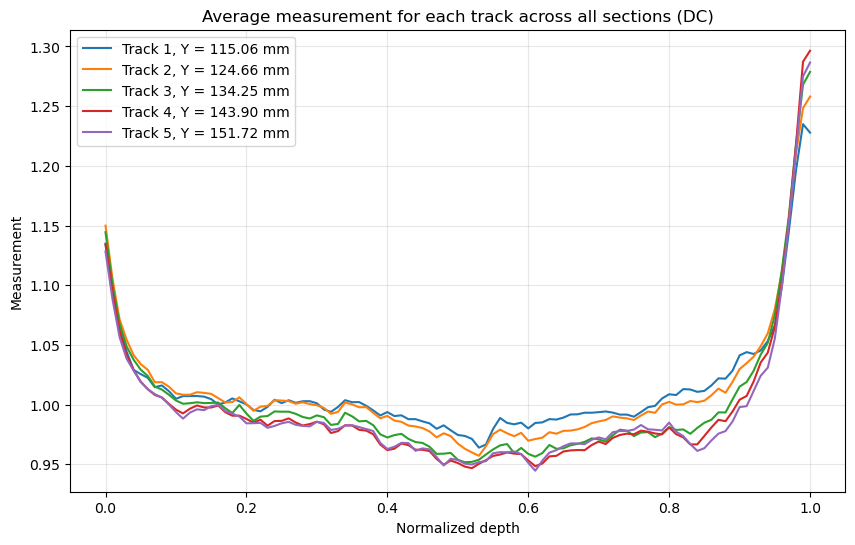

In [39]:
# Average each of the seven tracks across all sections

track_data = []

for section_index, d in enumerate(data_AC):
    depth = np.asarray(d.depth, dtype=float)
    measurements = np.asarray(d.meas, dtype=float)
    y_values = np.asarray(d.y, dtype=float)

    # Normalize depth within each section
    depth = depth - np.nanmin(depth)
    #depth = depth - np.nanmin(depth)
    depth_range = np.nanmax(depth)
    if depth_range > 0:
        depth = depth / depth_range

    # normalize measurements within each section
    measurements = measurements / np.nanmean(measurements)

    # Assign tracks by their ordered Y positions
    track_positions = np.sort(np.unique(y_values[np.isfinite(y_values)]))

    for track_index, y_value in enumerate(track_positions):
        mask = (
            (y_values == y_value)
            & np.isfinite(depth)
            & np.isfinite(measurements)
        )

        if not np.any(mask):
            continue

        bin_index = np.floor(depth[mask] * 100).astype(int)

        track_data.append(pd.DataFrame({
            "track": track_index + 1,
            "bin_start": bin_index / 100,
            "measurement": measurements[mask],
            "y_value": y_value,
        }))

# Combine all sections and average by track and normalized depth
all_tracks = pd.concat(track_data, ignore_index=True)

average_tracks = (
    all_tracks
    .groupby(["track", "bin_start"], as_index=False)
    .agg(
        measurement=("measurement", "mean"),
        y_value=("y_value", "mean")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

for track, track_average in average_tracks.groupby("track"):
    ax.plot(
        track_average["bin_start"],
        track_average["measurement"],
        label=f"Track {track}, Y = {track_average['y_value'].mean():.2f} mm"
    )

ax.set_title("Average measurement for each track across all sections (DC)")
ax.set_xlabel("Normalized depth")
ax.set_ylabel("Measurement")
ax.legend()
ax.grid(alpha=0.3)
plt.show()